In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [4]:
import joblib

xgb_model = joblib.load("xgboost(SW)_multiDistance_model.pkl")

In [6]:
import numpy as np

X_test_w = np.load("../data/Saved_Windows_features/X_test.npy")
y_test_w = np.load("../data/Saved_Windows_features/y_test.npy")

In [7]:
preds_xgb = xgb_model.predict(X_test_w)

print("Prediction shape:", preds_xgb.shape)
print("Target shape:", y_test_w.shape)

d:\ProteinPrediction\MainFiles\GPU_VENV\lib\site-packages\xgboost\core.py:751: UserWarning: [16:08:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Prediction shape: (24466, 4)
Target shape: (24466, 4)


In [10]:
overall_rmse = np.sqrt(mean_squared_error(y_test_w, preds_xgb))
overall_mae = mean_absolute_error(y_test_w, preds_xgb)
overall_r2 = r2_score(y_test_w, preds_xgb)

print("Overall XGBoost Metrics")
print("RMSE:", overall_rmse)
print("MAE:", overall_mae)
print("R2:", overall_r2)

Overall XGBoost Metrics
RMSE: 629.3886418581129
MAE: 175.75497436523438
R2: 0.6281043291091919


Per target metrics 

In [11]:
target_names = ["dist_i1", "dist_i2", "dist_i4", "dist_i8"]

rows = []

for i, target in enumerate(target_names):
    y_true = y_test_w[:, i]
    y_pred = preds_xgb[:, i]

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    pearson = np.corrcoef(y_true, y_pred)[0, 1]
    spearman = pd.Series(y_true).corr(pd.Series(y_pred), method="spearman")

    rows.append({
        "Target": target,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Pearson": pearson,
        "Spearman": spearman
    })

per_target_df = pd.DataFrame(rows)
per_target_df

,Target,RMSE,MAE,R2,Pearson,Spearman
0,dist_i1,295.764845,20.299410,0.690091,0.831788,0.089504
1,dist_i2,402.075941,68.001846,0.695796,0.834403,0.667609
2,dist_i4,582.610665,197.134766,0.670811,0.819123,0.774575
3,dist_i8,997.977611,417.583832,0.455691,0.675156,0.624968


In [12]:
per_target_df.to_csv("xgboost_per_target_metrics.csv", index=False)
print("Saved: xgboost_per_target_metrics.csv")

Saved: xgboost_per_target_metrics.csv


Actual vs predicted scatter plots

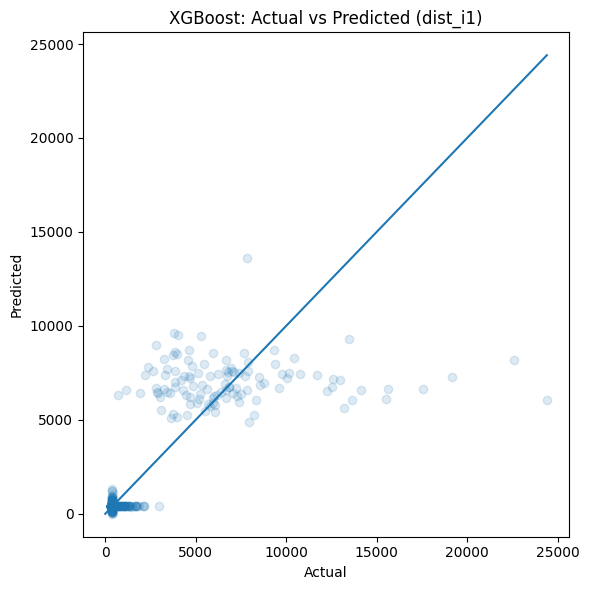

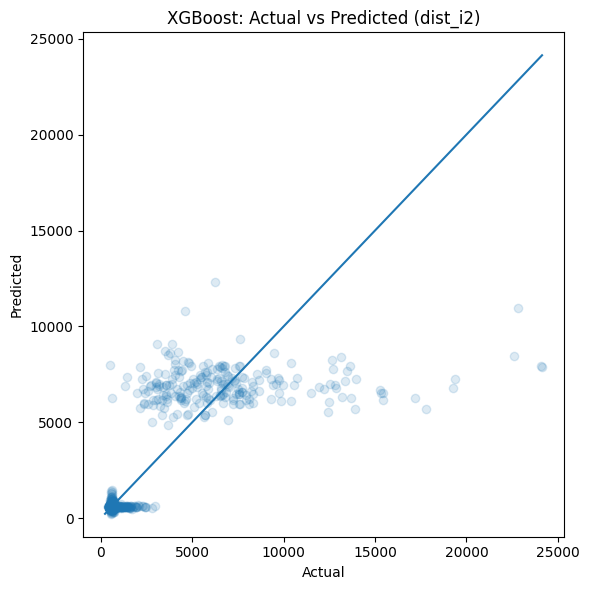

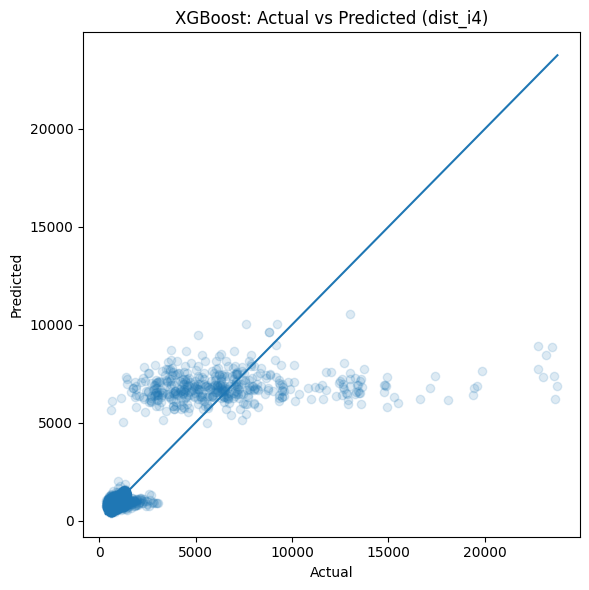

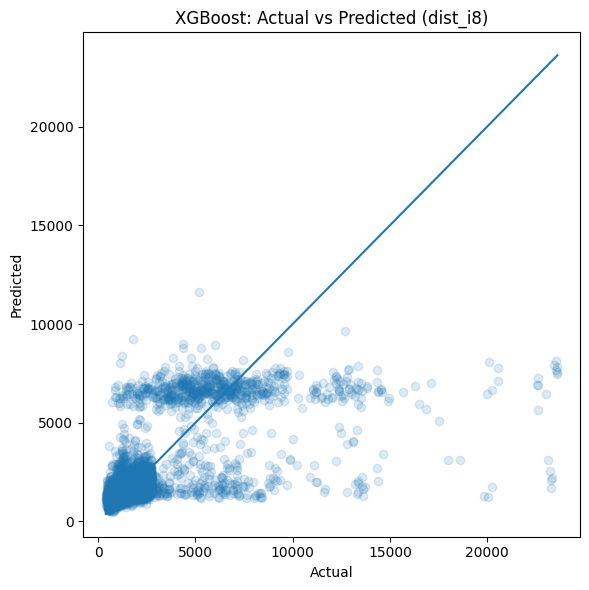

In [13]:
for i, target in enumerate(target_names):
    y_true = y_test_w[:, i]
    y_pred = preds_xgb[:, i]

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.15)

    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())

    plt.plot([min_val, max_val], [min_val, max_val])
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"XGBoost: Actual vs Predicted ({target})")
    plt.tight_layout()
    plt.show()

Semantic error patterns using residual graphs 

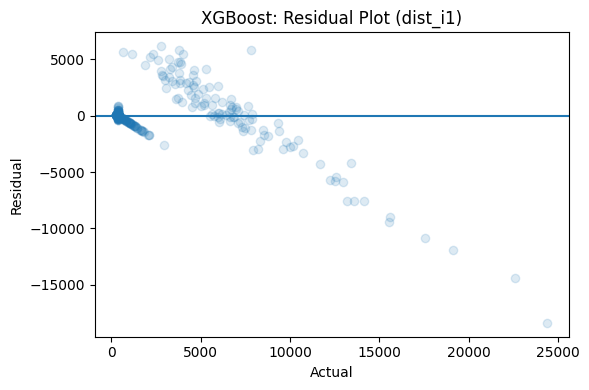

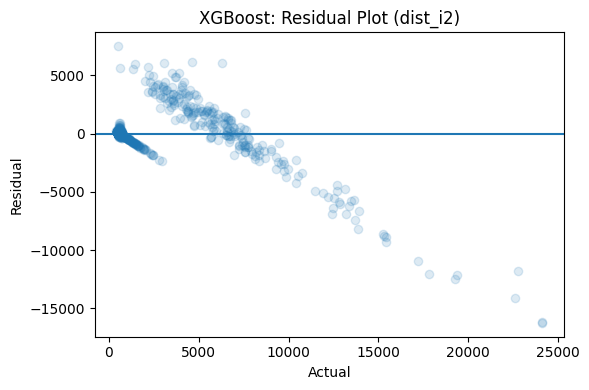

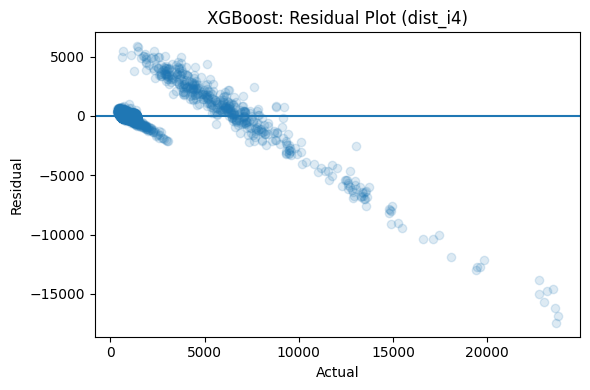

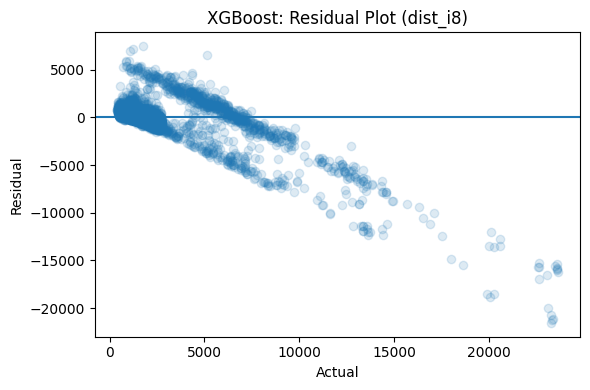

In [14]:
for i, target in enumerate(target_names):
    y_true = y_test_w[:, i]
    y_pred = preds_xgb[:, i]
    residuals = y_pred - y_true

    plt.figure(figsize=(6, 4))
    plt.scatter(y_true, residuals, alpha=0.15)
    plt.axhline(0)
    plt.xlabel("Actual")
    plt.ylabel("Residual")
    plt.title(f"XGBoost: Residual Plot ({target})")
    plt.tight_layout()
    plt.show()

Per target bar charts

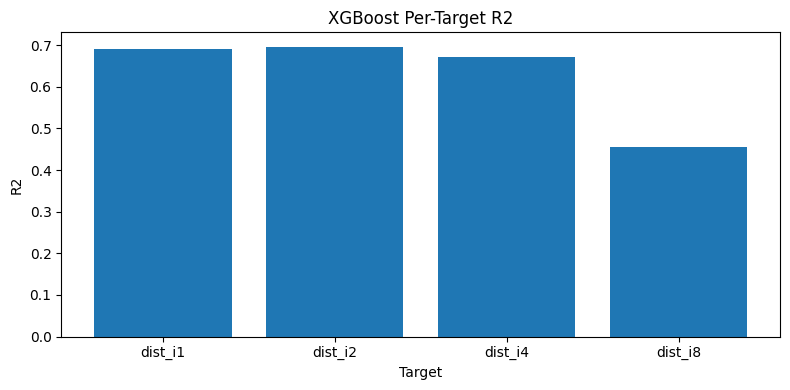

In [15]:
plt.figure(figsize=(8, 4))
plt.bar(per_target_df["Target"], per_target_df["R2"])
plt.xlabel("Target")
plt.ylabel("R2")
plt.title("XGBoost Per-Target R2")
plt.tight_layout()
plt.show()

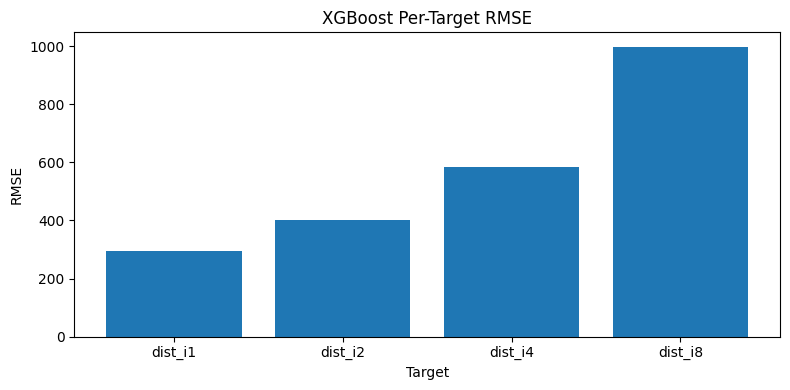

In [16]:
plt.figure(figsize=(8, 4))
plt.bar(per_target_df["Target"], per_target_df["RMSE"])
plt.xlabel("Target")
plt.ylabel("RMSE")
plt.title("XGBoost Per-Target RMSE")
plt.tight_layout()
plt.show()

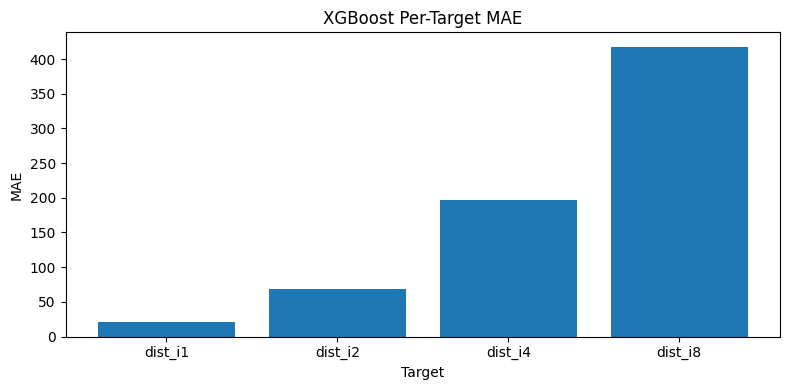

In [17]:
plt.figure(figsize=(8, 4))
plt.bar(per_target_df["Target"], per_target_df["MAE"])
plt.xlabel("Target")
plt.ylabel("MAE")
plt.title("XGBoost Per-Target MAE")
plt.tight_layout()
plt.show()

In [19]:
feature_importances = xgb_model.feature_importances_
print("Feature importance vector shape:", feature_importances.shape)

Feature importance vector shape: (451,)


Create feature names

In [20]:
base_feature_names = [f"Evo{i}" for i in range(1, 22)]

aa_feature_names = [
    "AA_A","AA_C","AA_D","AA_E","AA_F","AA_G","AA_H","AA_I","AA_K","AA_L",
    "AA_M","AA_N","AA_P","AA_Q","AA_R","AA_S","AA_T","AA_V","AA_W","AA_Y"
]

all_per_residue_features = base_feature_names + aa_feature_names

len(all_per_residue_features)

41

Sliding window names

In [21]:
window_offsets = list(range(-5, 6))

feature_names = []
for offset in window_offsets:
    for feat in all_per_residue_features:
        feature_names.append(f"{feat}_pos{offset}")

len(feature_names)

451

Importance of each feature

In [22]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

importance_df.head(20)

,Feature,Importance
0,Evo21_pos5,0.031428
1,AA_P_pos-5,0.031238
2,AA_P_pos-3,0.024442
3,Evo21_pos4,0.024323
4,AA_W_pos-3,0.024022
5,AA_P_pos-4,0.020965
6,Evo21_pos2,0.018948
7,AA_W_pos-2,0.014155
8,Evo1_pos4,0.014042
9,Evo1_pos5,0.013366


In [23]:
importance_df.to_csv("xgboost_feature_importance.csv", index=False)
print("Saved: xgboost_feature_importance.csv")

Saved: xgboost_feature_importance.csv


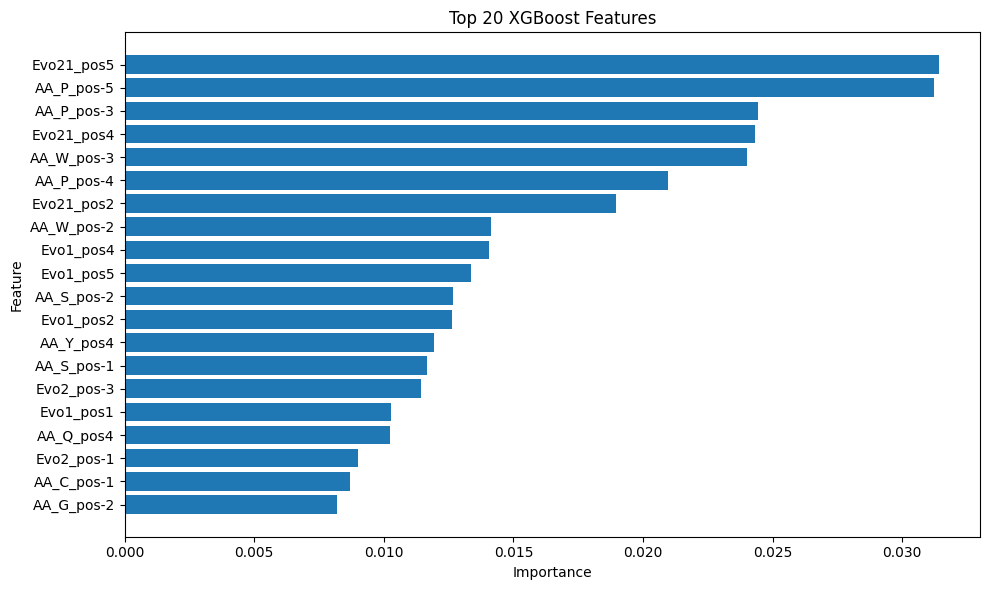

In [25]:
top_n = 20
top_imp = importance_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_imp["Feature"][::-1], top_imp["Importance"][::-1])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 XGBoost Features")
plt.tight_layout()
plt.show()